## Project objective

The project asks us to use exploratory data analysis to generate insights for a business stakeholder who is considering starting a movie studio.

The uploaded dataset is a TMDB movie dataset. It contains movie titles, genres represented by IDs, release dates, popularity, average ratings, and vote counts.

**Important limitation:** this dataset does not contain box-office revenue. Therefore, the analysis below uses popularity, ratings, vote counts, release patterns, and genre-count information as audience-interest indicators. It should not be described as a direct analysis of box-office revenue.

## 1. Import the libraries

We use pandas for data preparation and analysis, matplotlib and seaborn for visualization.


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


## 2. Load the data

The source file is compressed, so pandas can read it directly without manually extracting it.


In [50]:
file_path = r"zippedData/tmdb.movies.csv.gz"
movies = pd.read_csv(file_path, compression="gzip")

movies.head()


,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


## 3. Understand the dataset

Before cleaning, inspect the number of rows, columns, data types, missing values, and duplicate records.


In [51]:
print("Rows and columns:", movies.shape)
print("\nColumn names:")
print(movies.columns.tolist())

print("\nData types:")
print(movies.dtypes)

print("\nMissing values:")
print(movies.isna().sum())

print("\nDuplicate rows:", movies.duplicated().sum())
print("Duplicate movie IDs:", movies["id"].duplicated().sum())


Rows and columns: (26517, 10)

Column names:
['Unnamed: 0', 'genre_ids', 'id', 'original_language', 'original_title', 'popularity', 'release_date', 'title', 'vote_average', 'vote_count']

Data types:
Unnamed: 0             int64
genre_ids             object
id                     int64
original_language     object
original_title        object
popularity           float64
release_date          object
title                 object
vote_average         float64
vote_count             int64
dtype: object

Missing values:
Unnamed: 0           0
genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
dtype: int64

Duplicate rows: 0
Duplicate movie IDs: 1020


## 4. Data cleaning

The cleaning process will:

1. Remove the unnecessary `Unnamed: 0` column.
2. Remove duplicate records.
3. Standardize column names.
4. Convert `release_date` into a datetime column.
5. Convert numeric fields to numeric types.
6. Remove rows missing the core movie ID or release date.
7. Check that ratings are between 0 and 10.
8. Remove negative popularity and vote counts.
9. Make movie IDs unique.
10. Create `release_year` and `genre_count` columns for analysis.


In [52]:
# Remove the unnecessary index column
movies = movies.drop(columns=["Unnamed: 0"], errors="ignore")

# Remove exact duplicate records
movies = movies.drop_duplicates()

# Standardize column names
movies.columns = (
    movies.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Convert release date to datetimec
movies["release_date"] = pd.to_datetime(
    movies["release_date"], errors="coerce"
)

# Convert numeric columns
numeric_columns = ["id", "popularity", "vote_average", "vote_count"]

for column in numeric_columns:
    movies[column] = pd.to_numeric(movies[column], errors="coerce")

# Remove rows missing essential fields
movies = movies.dropna(subset=["id", "release_date"])

# Keep valid numeric values
movies = movies[movies["vote_average"].between(0, 10)]
movies = movies[movies["vote_count"] >= 0]
movies = movies[movies["popularity"] >= 0]

# Make movie IDs unique
movies = movies.drop_duplicates(subset=["id"], keep="first")

# Create useful analysis columns
movies["release_year"] = movies["release_date"].dt.year
movies["genre_count"] = movies["genre_ids"].str.count(",") + 1

movies.head()


,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count,release_year,genre_count
0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788,2010,3
1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610,2010,4
2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368,2010,3
3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174,1995,3
4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186,2010,3


## 5. Validate the cleaned data

Validation confirms that the cleaning operations produced a usable dataset.


In [53]:
print("Cleaned shape:", movies.shape)

print("\nMissing values after cleaning:")
print(movies.isna().sum())

print("\nDuplicate rows after cleaning:", movies.duplicated().sum())
print("Duplicate movie IDs after cleaning:", movies["id"].duplicated().sum())

print("\nRelease date range:")
print(movies["release_date"].min(), "to", movies["release_date"].max())

print("\nRating range:")
print(movies["vote_average"].min(), "to", movies["vote_average"].max())


Cleaned shape: (25497, 11)

Missing values after cleaning:
genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
release_year         0
genre_count          0
dtype: int64

Duplicate rows after cleaning: 0
Duplicate movie IDs after cleaning: 0

Release date range:
1930-04-29 00:00:00 to 2020-12-25 00:00:00

Rating range:
0.0 to 10.0


### 7. Decode the TMDB Genre IDs

The `genre_ids` column in the TMDB movies dataset contains numerical IDs rather than readable genre names. To make the data easier to understand and analyze, we will create a dictionary that maps each TMDB genre ID to its corresponding genre name.

For example, the ID `12` represents **Adventure**, `14` represents **Fantasy**, and `28` represents **Action**.

We will then use this mapping to convert the genre IDs into meaningful genre names that can be used for further analysis and visualization.

In [54]:
# TMDB genre ID mapping
genre_map = {
    12: "Adventure",
    14: "Fantasy",
    16: "Animation",
    18: "Drama",
    27: "Horror",
    28: "Action",
    35: "Comedy",
    36: "History",
    37: "Western",
    53: "Thriller",
    80: "Crime",
    99: "Documentary",
    878: "Science Fiction",
    9648: "Mystery",
    10402: "Music",
    10749: "Romance",
    10751: "Family",
    10752: "War",
    10770: "TV Movie"
}

# Convert string representation of list into actual list
import ast

movies["genre_ids"] = movies["genre_ids"].apply(ast.literal_eval)

# Decode IDs into genre names
movies["genres"] = movies["genre_ids"].apply(
    lambda ids: ", ".join(genre_map.get(i, "Unknown") for i in ids)
)

movies[["title", "genres"]].head()

,title,genres
0,Harry Potter and the Deathly Hallows: Part 1,"Adventure, Fantasy, Family"
1,How to Train Your Dragon,"Fantasy, Adventure, Animation, Family"
2,Iron Man 2,"Adventure, Action, Science Fiction"
3,Toy Story,"Animation, Comedy, Family"
4,Inception,"Action, Science Fiction, Adventure"


### 8. Loading the tn.movie_budget.csv.gz dataset

In [55]:
budgets = pd.read_csv(
    "zippedData/tn.movie_budgets.csv.gz"
)

budgets.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"



### 9. Cleaning the dataset and converting the money column strings to numbers

In [56]:
budgets.columns = (
    budgets.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

budgets.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [57]:
money_columns = [
    "production_budget",
    "domestic_gross",
    "worldwide_gross"
]

for col in money_columns:
    budgets[col] = (
        budgets[col]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

### 10. Converting the release date

In [58]:
budgets["release_date"] = pd.to_datetime(
    budgets["release_date"],
    errors="coerce"
)

budgets["release_year"] = budgets["release_date"].dt.year

### 11. Merge the Budget Data with `tmdb.movies`

The budget dataset and the `tmdb.movies` dataset may use different movie ID systems. Therefore, using the movie ID alone may not produce reliable matches.

To improve the accuracy of the merge, we will match the datasets using both the **movie title** and **release year**. This allows us to connect the budget information with the corresponding TMDB movie records while reducing the risk of incorrect matches.

The merged dataset will allow us to analyze **production budget, movie genres, ratings, and popularity** together.

In [59]:
merged = budgets.merge(
    movies,
    left_on=["movie", "release_year"],
    right_on=["title", "release_year"],
    how="inner"
)

merged.head()

,id_x,release_date_x,movie,production_budget,domestic_gross,worldwide_gross,release_year,genre_ids,id_y,original_language,original_title,popularity,release_date_y,title,vote_average,vote_count,genre_count,genres
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,2009,"[28, 12, 14, 878]",19995,en,Avatar,26.526,2009-12-18,Avatar,7.4,18676,4,"Action, Adventure, Fantasy, Science Fiction"
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,2011,"[12, 28, 14]",1865,en,Pirates of the Caribbean: On Stranger Tides,30.579,2011-05-20,Pirates of the Caribbean: On Stranger Tides,6.4,8571,3,"Adventure, Action, Fantasy"
2,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,2015,"[28, 12, 878]",99861,en,Avengers: Age of Ultron,44.383,2015-05-01,Avengers: Age of Ultron,7.3,13457,3,"Action, Adventure, Science Fiction"
3,7,2018-04-27,Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,2018,"[12, 28, 14]",299536,en,Avengers: Infinity War,80.773,2018-04-27,Avengers: Infinity War,8.3,13948,3,"Adventure, Action, Fantasy"
4,9,2017-11-17,Justice League,300000000.0,229024295.0,6.559452e+08,2017,"[28, 12, 14, 878]",141052,en,Justice League,34.953,2017-11-17,Justice League,6.2,7510,4,"Action, Adventure, Fantasy, Science Fiction"


In [60]:
print("Budget records:", len(budgets))
print("TMDB records:", len(movies))
print("Merged records:", len(merged))

Budget records: 5782
TMDB records: 25497
Merged records: 1610


### 3. Cross-check the Ratings

The TMDB dataset contains a `vote_average` column that represents the average rating given to each movie. The IMDb dataset may contain a similar rating in the `averagerating` column.

After merging the datasets, we can compare these two rating measures to identify whether the ratings are generally consistent across TMDB and IMDb.

We will also calculate the difference between the two ratings. This will help identify movies where the TMDB and IMDb ratings differ significantly.

### Loading the IMDb data and cleaning it before the merge

In [61]:
import sqlite3
import pandas as pd
import zipfile 
with zipfile.ZipFile("zippedData/im.db.zip", "r") as zip_ref:
    zip_ref.extractall("zippedData")
# Connect to IMDb database
conn_imdb = sqlite3.connect("zippedData/im.db")

# Load movie information
imdb_movies = pd.read_sql_query("""
    SELECT
        movie_id,
        primary_title,
        original_title,
        start_year,
        runtime_minutes,
        genres
    FROM movie_basics
""", conn_imdb)

# Load IMDb ratings
imdb_ratings = pd.read_sql_query("""
    SELECT
        movie_id,
        averagerating,
        numvotes
    FROM movie_ratings
""", conn_imdb)

imdb_movies.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [62]:
# Remove leading/trailing spaces from titles
imdb_movies["primary_title"] = (
    imdb_movies["primary_title"]
    .astype("string")
    .str.strip()
)

# Convert year to numeric
imdb_movies["start_year"] = pd.to_numeric(
    imdb_movies["start_year"],
    errors="coerce"
)

# Remove records without a title or release year
imdb_movies = imdb_movies.dropna(
    subset=["primary_title", "start_year"]
)

# Convert year to integer
imdb_movies["start_year"] = imdb_movies["start_year"].astype(int)

# Remove duplicate movie IDs
imdb_movies = imdb_movies.drop_duplicates(
    subset="movie_id"
)

imdb_movies.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [63]:
# Convert ratings and votes to numeric
imdb_ratings["averagerating"] = pd.to_numeric(
    imdb_ratings["averagerating"],
    errors="coerce"
)

imdb_ratings["numvotes"] = pd.to_numeric(
    imdb_ratings["numvotes"],
    errors="coerce"
)

# Remove missing ratings
imdb_ratings = imdb_ratings.dropna(
    subset=["averagerating"]
)

# Keep ratings between 0 and 10
imdb_ratings = imdb_ratings[
    imdb_ratings["averagerating"].between(0, 10)
]

# Remove duplicate movie IDs
imdb_ratings = imdb_ratings.drop_duplicates(
    subset="movie_id"
)

imdb_ratings.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [64]:
imdb = imdb_movies.merge(
    imdb_ratings,
    on="movie_id",
    how="inner"
)

imdb.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy",6.5,119


In [65]:
imdb_merge = imdb.rename(
    columns={
        "primary_title": "title",
        "start_year": "release_year"
    }
)

imdb_merge = imdb_merge[
    [
        "movie_id",
        "title",
        "release_year",
        "genres",
        "averagerating",
        "numvotes"
    ]
]

imdb_merge.head()

,movie_id,title,release_year,genres,averagerating,numvotes
0,tt0063540,Sunghursh,2013,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,2019,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,2018,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,2018,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,2017,"Comedy,Drama,Fantasy",6.5,119


In [66]:
movies["title"] = (
    movies["title"]
    .astype("string")
    .str.strip()
)

movies["release_year"] = pd.to_numeric(
    movies["release_year"],
    errors="coerce"
)

movies = movies.dropna(
    subset=["title", "release_year"]
)

movies["release_year"] = movies["release_year"].astype(int)

In [67]:
tmdb_imdb = movies.merge(
    imdb_merge,
    on=["title", "release_year"],
    how="inner",
    suffixes=("_tmdb", "_imdb")
)

tmdb_imdb.head()

,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count,release_year,genre_count,genres_tmdb,movie_id,genres_imdb,averagerating,numvotes
0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788,2010,3,"Adventure, Fantasy, Family",tt0926084,"Adventure,Fantasy,Mystery",7.7,425530
1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610,2010,4,"Fantasy, Adventure, Animation, Family",tt0892769,"Action,Adventure,Animation",8.1,611299
2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368,2010,3,"Adventure, Action, Science Fiction",tt1228705,"Action,Adventure,Sci-Fi",7.0,657690
3,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186,2010,3,"Action, Science Fiction, Adventure",tt1375666,"Action,Adventure,Sci-Fi",8.8,1841066
4,"[12, 14, 10751]",32657,en,Percy Jackson & the Olympians: The Lightning T...,26.691,2010-02-11,Percy Jackson & the Olympians: The Lightning T...,6.1,4229,2010,3,"Adventure, Fantasy, Family",tt0814255,"Adventure,Family,Fantasy",5.9,165108


### Cross-Checking TMDB and IMDb Ratings

In [68]:
tmdb_imdb["rating_difference"] = (
    tmdb_imdb["vote_average"]
    - tmdb_imdb["averagerating"]
)

tmdb_imdb[
    [
        "title",
        "release_year",
        "vote_average",
        "averagerating",
        "rating_difference"
    ]
].head(20)

,title,release_year,vote_average,averagerating,rating_difference
0,Harry Potter and the Deathly Hallows: Part 1,2010,7.7,7.7,0.0
1,How to Train Your Dragon,2010,7.7,8.1,-0.4
2,Iron Man 2,2010,6.8,7.0,-0.2
3,Inception,2010,8.3,8.8,-0.5
4,Percy Jackson & the Olympians: The Lightning T...,2010,6.1,5.9,0.2
5,Toy Story 3,2010,7.7,8.3,-0.6
6,Despicable Me,2010,7.2,7.7,-0.5
7,Megamind,2010,6.8,7.3,-0.5
8,Alice in Wonderland,2010,6.6,6.5,0.1
9,Alice in Wonderland,2010,6.6,6.5,0.1


## Creating Movie Budget Tiers

To make it easier to compare movies based on their production budgets, the movies are divided into three budget categories: **Low**, **Mid**, and **High**.

The `production_budget` column is used to create these categories:

- **Low Budget:** $0 to $10 million
- **Mid Budget:** More than $10 million to $50 million
- **High Budget:** More than $50 million

The `pd.cut()` function is used to assign each movie to the appropriate budget tier. This creates a new column called `budget_tier`.

This categorization allows us to analyze and visualize how movie performance differs between low-, mid-, and high-budget productions.

In [69]:
# Create budget tiers based on production budget

bins = [0, 10_000_000, 50_000_000, float("inf")]
labels = ["Low", "Mid", "High"]

merged["budget_tier"] = pd.cut(
    merged["production_budget"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# View the results
merged[["movie", "production_budget", "budget_tier"]].head(10)

,movie,production_budget,budget_tier
0,Avatar,425000000.0,High
1,Pirates of the Caribbean: On Stranger Tides,410600000.0,High
2,Avengers: Age of Ultron,330600000.0,High
3,Avengers: Infinity War,300000000.0,High
4,Justice League,300000000.0,High
5,Spectre,300000000.0,High
6,The Dark Knight Rises,275000000.0,High
7,Solo: A Star Wars Story,275000000.0,High
8,The Lone Ranger,275000000.0,High
9,John Carter,275000000.0,High


In [70]:
merged["budget_tier"].value_counts()

budget_tier
Mid     664
Low     536
High    410
Name: count, dtype: int64

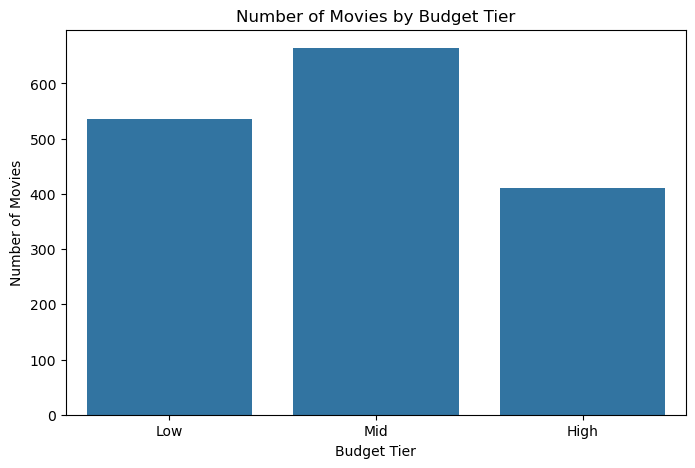

In [71]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=merged,
    x="budget_tier",
    order=["Low", "Mid", "High"]
)

plt.title("Number of Movies by Budget Tier")
plt.xlabel("Budget Tier")
plt.ylabel("Number of Movies")
plt.show()